# HW 5
## Neural Networks w/ Keras
### Dirks Wright

This notebook uses the Adult Census income dataset to predict whether a person earns more than 50K.

In [16]:
### load packages
import os
import random
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import optuna
from optuna.samplers import TPESampler

### set random seeds for reproducibility
RANDOM_STATE = 222

def reset_random_seeds(seed=RANDOM_STATE):
    np.random.seed(seed)
    random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


reset_random_seeds()
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 120)
pd.set_option("display.precision", 4)


## Loading and Preprocessing


In [17]:
### load dataset
df = pd.read_csv("adult.csv")

### clean strings and replace missing value marker.
string_columns = df.select_dtypes(include=["object", "string"]).columns
for column in string_columns:
    df[column] = df[column].astype("string").str.strip()

df = df.replace("?", np.nan)
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1}).astype("int32")

### new shape of dataset
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Positive class rate (>50K): {df['income'].mean():.3f}")

missing_summary = (
    df.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_rate"] = missing_summary["missing_count"] / len(df)

display(df.head())
display(missing_summary)


Rows: 48,842
Columns: 15
Positive class rate (>50K): 0.239


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,<NA>,103497,Some-college,10,Never-married,<NA>,Own-child,White,Female,0,0,30,United-States,0


,missing_count,missing_rate
occupation,2809,0.0575
workclass,2799,0.0573
native-country,857,0.0175


## Feature Engineering


In [18]:
### feature engineering function
def add_engineered_features(data):
    data = data.copy()
    ### numerical transformations
    data["capital-net"] = data["capital-gain"] - data["capital-loss"]
    data["capital-activity"] = (
        (data["capital-gain"] > 0) | (data["capital-loss"] > 0)
    ).astype("int32")
    data["log-capital-gain"] = np.log1p(data["capital-gain"])
    data["log-capital-loss"] = np.log1p(data["capital-loss"])
    data["hours-over-40"] = (data["hours-per-week"] > 40).astype("int32")
    data["age-group"] = pd.cut(
        data["age"],
        bins=[0, 25, 35, 45, 55, 65, np.inf],
        labels=["under_25", "25_34", "35_44", "45_54", "55_64", "65_plus"],
        include_lowest=True,
    )
    ### categorical transformations
    data["is-married"] = (
        data["marital-status"].fillna("").str.startswith("Married").astype("int32")
    )
    data["is-us-native"] = (
        data["native-country"].fillna("").eq("United-States").astype("int32")
    )
    ### interaction features
    data["education-hours"] = data["educational-num"] * data["hours-per-week"]

    return data

### prepare data for modeling
model_df = add_engineered_features(df)
X = model_df.drop(columns=["income"])
y = model_df["income"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

numeric_features = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

## convert pandas string/category missing values 
for split in (X_train, X_val, X_test):
    for column in categorical_features:
        split[column] = split[column].astype("object").where(split[column].notna(), np.nan)

### transformers and preprocessing for numeric and categorical features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

### fit and transform data for neural network
X_train_nn = preprocessor.fit_transform(X_train).astype("float32")
X_val_nn = preprocessor.transform(X_val).astype("float32")
X_test_nn = preprocessor.transform(X_test).astype("float32")

print(f"Train shape:      {X_train_nn.shape}")
print(f"Validation shape: {X_val_nn.shape}")
print(f"Test shape:       {X_test_nn.shape}")
print(f"Numeric features before encoding: {len(numeric_features)}")
print(f"Categorical features before encoding: {len(categorical_features)}")
print(f"Encoded/scaled model inputs: {X_train_nn.shape[1]}")
print("\nClass balance by split:")
display(
    pd.Series(
        {
            "train": y_train.mean(),
            "validation": y_val.mean(),
            "test": y_test.mean(),
        },
        name="positive_rate",
    ).to_frame()
)


Train shape:      (31258, 121)
Validation shape: (7815, 121)
Test shape:       (9769, 121)
Numeric features before encoding: 14
Categorical features before encoding: 9
Encoded/scaled model inputs: 121

Class balance by split:


,positive_rate
train,0.2393
validation,0.2393
test,0.2393


## Model Helpers


In [19]:
### custom Keras metric for threshold-based balanced accuracy
class BalancedAccuracy(keras.metrics.Metric):
    def __init__(self, name="balanced_accuracy", threshold=0.50, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name="tp", initializer="zeros")
        self.true_negatives = self.add_weight(name="tn", initializer="zeros")
        self.false_positives = self.add_weight(name="fp", initializer="zeros")
        self.false_negatives = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        y_pred = tf.reshape(tf.cast(y_pred >= self.threshold, tf.float32), [-1])

        if sample_weight is None:
            sample_weight = tf.ones_like(y_true)
        else:
            sample_weight = tf.reshape(tf.cast(sample_weight, tf.float32), [-1])

        self.true_positives.assign_add(tf.reduce_sum(sample_weight * y_true * y_pred))
        self.true_negatives.assign_add(tf.reduce_sum(sample_weight * (1 - y_true) * (1 - y_pred)))
        self.false_positives.assign_add(tf.reduce_sum(sample_weight * (1 - y_true) * y_pred))
        self.false_negatives.assign_add(tf.reduce_sum(sample_weight * y_true * (1 - y_pred)))

    def result(self):
        positive_recall = tf.math.divide_no_nan(
            self.true_positives, self.true_positives + self.false_negatives
        )
        negative_recall = tf.math.divide_no_nan(
            self.true_negatives, self.true_negatives + self.false_positives
        )
        return 0.5 * (positive_recall + negative_recall)

    def reset_state(self):
        self.true_positives.assign(0.0)
        self.true_negatives.assign(0.0)
        self.false_positives.assign(0.0)
        self.false_negatives.assign(0.0)

### function to build model
def build_model(
    input_dim,
    hidden_units=(64, 32),
    dropout_rate=0.0,
    l2_strength=0.0,
    learning_rate=0.001,
    batch_norm=False,
):
    tf.keras.backend.clear_session()
    reset_random_seeds()

    inputs = keras.Input(shape=(input_dim,), name="features")
    x = inputs
    regularizer = regularizers.l2(l2_strength) if l2_strength and l2_strength > 0 else None

    for units in hidden_units:
        x = layers.Dense(units, activation="relu", kernel_regularizer=regularizer)(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation="sigmoid", name="income_probability")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", BalancedAccuracy(name="balanced_accuracy")],
    )
    return model

### training helper function
def train_model(
    model,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    epochs=40,
    batch_size=256,
    patience=5,
):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_balanced_accuracy",
        mode="max",
        patience=patience,
        min_delta=0.001,
        restore_best_weights=True,
    )
    return model.fit(
        X_train_data,
        y_train_data,
        validation_data=(X_val_data, y_val_data),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0,
    )

### threshold-based metrics from predicted probabilities
def metrics_from_probabilities(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype("int32")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

### evaluation helper function
def evaluate_model(model, X_data, y_true, threshold=0.50):
    y_prob = model.predict(X_data, verbose=0).ravel()
    metrics = metrics_from_probabilities(y_true, y_prob, threshold=threshold)
    y_pred = (y_prob >= threshold).astype("int32")
    return metrics, confusion_matrix(y_true, y_pred), y_prob

### validation-only threshold search for balanced accuracy
def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.10, 0.901, 0.005), 3)

    threshold_results = []
    for threshold in thresholds:
        metrics = metrics_from_probabilities(y_true, y_prob, threshold=threshold)
        threshold_results.append({"threshold": threshold, **metrics})

    threshold_results = pd.DataFrame(threshold_results)
    best_row = threshold_results.sort_values(
        ["balanced_accuracy", "f1"], ascending=False
    ).iloc[0]
    best_threshold = float(best_row["threshold"])
    best_metrics = best_row.drop(labels=["threshold"]).to_dict()

    return best_threshold, best_metrics, threshold_results

### function to summarize training history
def summarize_history(history):
    hist = pd.DataFrame(history.history)
    best_epoch = hist["val_balanced_accuracy"].idxmax() + 1
    return {
        "epochs_run": len(hist),
        "best_epoch": best_epoch,
        "best_val_balanced_accuracy_in_history": hist["val_balanced_accuracy"].max(),
        "best_val_loss_in_history": hist["val_loss"].min(),
    }


## Baseline Neural Network


In [20]:
### baseline model configuration and training
### define input dimension for model building
input_dim = X_train_nn.shape[1]
### baseline configuration
baseline_config = {
    "model": "Baseline",
    "change_tested": "Reference model",
    "hidden_units": (32,),
    "dropout_rate": 0.0,
    "l2_strength": 0.0,
    "learning_rate": 0.001,
    "batch_norm": False,
    "batch_size": 256,
}
### build, train, and evaluate baseline model
baseline_model = build_model(
    input_dim=input_dim,
    hidden_units=baseline_config["hidden_units"],
    dropout_rate=baseline_config["dropout_rate"],
    l2_strength=baseline_config["l2_strength"],
    learning_rate=baseline_config["learning_rate"],
    batch_norm=baseline_config["batch_norm"],
)
baseline_history = train_model(
    baseline_model,
    X_train_nn,
    y_train,
    X_val_nn,
    y_val,
    epochs=40,
    batch_size=baseline_config["batch_size"],
    patience=5,
)
baseline_metrics, baseline_cm, baseline_probs = evaluate_model(baseline_model, X_val_nn, y_val)
baseline_summary = {**baseline_config, **baseline_metrics, **summarize_history(baseline_history)}

display(pd.DataFrame([baseline_summary]))


,model,change_tested,hidden_units,dropout_rate,l2_strength,learning_rate,batch_norm,batch_size,accuracy,balanced_accuracy,precision,recall,f1,epochs_run,best_epoch,best_val_balanced_accuracy_in_history,best_val_loss_in_history
0,Baseline,Reference model,"(32,)",0.0,0.0,0.001,False,256,0.8601,0.7757,0.7558,0.6139,0.6775,9,7,0.7766,0.3008


## 3 Experiments


1. model capacity increased by adding a wider second hidden layer.
2. architecture kept and added dropout plus light L2 regularization.
3. regularized architecture kept and changed the training setup with batch normalization and a lower learning rate.


In [21]:
### experimental configurations
experiment_configs = [
    {
        "model": "Wider/deeper",
        "change_tested": "Architecture capacity",
        "hidden_units": (128, 64),
        "dropout_rate": 0.0,
        "l2_strength": 0.0,
        "learning_rate": 0.001,
        "batch_norm": False,
        "batch_size": 256,
    },
    {
        "model": "Regularized",
        "change_tested": "Dropout + L2",
        "hidden_units": (128, 64),
        "dropout_rate": 0.30,
        "l2_strength": 1e-4,
        "learning_rate": 0.001,
        "batch_norm": False,
        "batch_size": 256,
    },
    {
        "model": "BatchNorm + lower LR",
        "change_tested": "Training setup",
        "hidden_units": (128, 64),
        "dropout_rate": 0.30,
        "l2_strength": 1e-4,
        "learning_rate": 0.0005,
        "batch_norm": True,
        "batch_size": 256,
    },
]

### experimental results
experiment_results = [baseline_summary]
experiment_histories = {"Baseline": baseline_history}
experiment_models = {"Baseline": baseline_model}

for config in experiment_configs:
    print(f"Training {config['model']}...")
    model = build_model(
        input_dim=input_dim,
        hidden_units=config["hidden_units"],
        dropout_rate=config["dropout_rate"],
        l2_strength=config["l2_strength"],
        learning_rate=config["learning_rate"],
        batch_norm=config["batch_norm"],
    )
    history = train_model(
        model,
        X_train_nn,
        y_train,
        X_val_nn,
        y_val,
        epochs=40,
        batch_size=config["batch_size"],
        patience=5,
    )
    metrics, cm, probs = evaluate_model(model, X_val_nn, y_val)
    experiment_results.append({**config, **metrics, **summarize_history(history)})
    experiment_histories[config["model"]] = history
    experiment_models[config["model"]] = model

experiment_results = pd.DataFrame(experiment_results)
metric_columns = [
    "model",
    "change_tested",
    "hidden_units",
    "dropout_rate",
    "l2_strength",
    "learning_rate",
    "batch_norm",
    "epochs_run",
    "best_epoch",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
]

display(experiment_results[metric_columns].sort_values("balanced_accuracy", ascending=False))


Training Wider/deeper...
Training Regularized...
Training BatchNorm + lower LR...


,model,change_tested,hidden_units,dropout_rate,l2_strength,learning_rate,batch_norm,epochs_run,best_epoch,accuracy,balanced_accuracy,precision,recall,f1
1,Wider/deeper,Architecture capacity,"(128, 64)",0.0,0.0000,0.0010,False,9,6,0.8596,0.7961,0.7210,0.6743,0.6969
3,BatchNorm + lower LR,Training setup,"(128, 64)",0.3,0.0001,0.0005,True,6,1,0.8386,0.7832,0.6583,0.6770,0.6675
2,Regularized,Dropout + L2,"(128, 64)",0.3,0.0001,0.0010,False,9,7,0.8621,0.7799,0.7578,0.6225,0.6835
0,Baseline,Reference model,"(32,)",0.0,0.0000,0.0010,False,9,7,0.8601,0.7757,0.7558,0.6139,0.6775


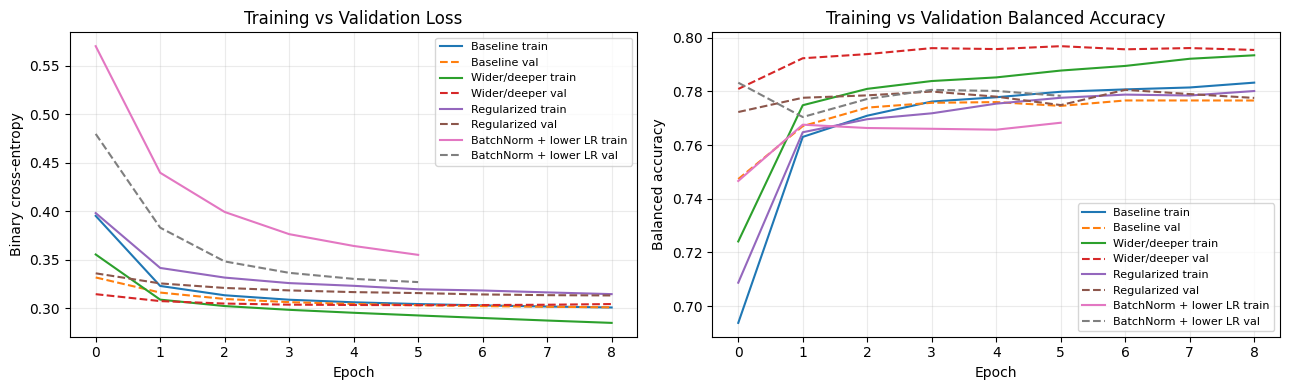

In [22]:
### plot training histories
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for model_name, history in experiment_histories.items():
    hist = pd.DataFrame(history.history)
    axes[0].plot(hist["loss"], label=f"{model_name} train")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"{model_name} val")
    axes[1].plot(hist["balanced_accuracy"], label=f"{model_name} train")
    axes[1].plot(hist["val_balanced_accuracy"], linestyle="--", label=f"{model_name} val")

axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[1].set_title("Training vs Validation Balanced Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Balanced accuracy")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Systematic Tuning w/ Optuna



In [23]:
### hyperparameter tuning with Optuna
### set number of trials
N_TRIALS = 20

### helper function to extract hidden layer units from trial parameters
def hidden_units_from_params(params):
    return tuple(params[f"units_l{i + 1}"] for i in range(params["n_layers"]))

### Optuna objective function
def objective(trial):
    ### define layers
    n_layers = trial.suggest_int("n_layers", 1, 3)
    for i in range(n_layers):
        trial.suggest_categorical(f"units_l{i + 1}", [32, 64, 128, 256])
    ### define parameters
    params = {
        "n_layers": n_layers,
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.40, step=0.10),
        "l2_strength": trial.suggest_float("l2_strength", 1e-6, 1e-3, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "batch_norm": trial.suggest_categorical("batch_norm", [False, True]),
        "batch_size": trial.suggest_categorical("batch_size", [128, 256, 512]),
    }
    ### iterate over layers to add units to params for model building
    for i in range(n_layers):
        params[f"units_l{i + 1}"] = trial.params[f"units_l{i + 1}"]
    ###build, train, and evaluate model
    model = build_model(
        input_dim=input_dim,
        hidden_units=hidden_units_from_params(params),
        dropout_rate=params["dropout_rate"],
        l2_strength=params["l2_strength"],
        learning_rate=params["learning_rate"],
        batch_norm=params["batch_norm"],
    )
    history = train_model(
        model,
        X_train_nn,
        y_train,
        X_val_nn,
        y_val,
        epochs=35,
        batch_size=params["batch_size"],
        patience=4,
    )
    _, _, val_probs = evaluate_model(model, X_val_nn, y_val, threshold=0.50)
    best_threshold, metrics, _ = find_best_threshold(y_val, val_probs)
    trial.set_user_attr("epochs_run", len(history.history["loss"]))
    trial.set_user_attr("best_threshold", best_threshold)
    trial.set_user_attr("val_accuracy", metrics["accuracy"])
    trial.set_user_attr("val_balanced_accuracy", metrics["balanced_accuracy"])
    trial.set_user_attr("val_f1", metrics["f1"])
    return metrics["balanced_accuracy"]

### create Optuna study and optimize
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
)

### strongest controlled-experiment setup
study.enqueue_trial(
    {
        "n_layers": 2,
        "units_l1": 128,
        "units_l2": 64,
        "dropout_rate": 0.30,
        "l2_strength": 1e-4,
        "learning_rate": 0.001,
        "batch_norm": False,
        "batch_size": 256,
    }
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

### summarize tuning results
trials_df = study.trials_dataframe(
    attrs=("number", "value", "params", "user_attrs", "state")
).sort_values("value", ascending=False)

print(f"Best validation balanced accuracy: {study.best_value:.4f}")
print("Best parameters:")
print(study.best_params)
display(trials_df.head(10))


Best validation balanced accuracy: 0.8356
Best parameters:
{'n_layers': 2, 'units_l1': 256, 'units_l2': 256, 'dropout_rate': 0.30000000000000004, 'l2_strength': 3.017139607410965e-06, 'learning_rate': 0.0006914962820215104, 'batch_norm': True, 'batch_size': 128}


,number,value,params_batch_norm,params_batch_size,params_dropout_rate,params_l2_strength,params_learning_rate,params_n_layers,params_units_l1,params_units_l2,params_units_l3,user_attrs_best_threshold,user_attrs_epochs_run,user_attrs_val_accuracy,user_attrs_val_balanced_accuracy,user_attrs_val_f1,state
15,15,0.8356,True,128,0.3,3.0171e-06,0.0007,2,256,256.0,NaN,0.245,9,0.8235,0.8356,0.6996,COMPLETE
8,8,0.8353,True,128,0.2,1.0199e-06,0.0026,2,256,32.0,NaN,0.220,10,0.8155,0.8353,0.6937,COMPLETE
6,6,0.8348,True,128,0.4,2.2383e-05,0.0030,3,256,64.0,64.0,0.260,16,0.8194,0.8348,0.6961,COMPLETE
5,5,0.8345,True,512,0.4,1.3042e-06,0.0022,3,128,128.0,64.0,0.290,13,0.8266,0.8345,0.7011,COMPLETE
14,14,0.8345,False,128,0.4,1.3402e-05,0.0016,3,256,64.0,128.0,0.255,12,0.8260,0.8345,0.7006,COMPLETE
13,13,0.8339,True,128,0.3,4.3435e-04,0.0028,1,256,NaN,NaN,0.240,9,0.8128,0.8339,0.6909,COMPLETE
16,16,0.8339,True,128,0.3,2.9598e-06,0.0004,2,256,256.0,NaN,0.215,9,0.8161,0.8339,0.6931,COMPLETE
9,9,0.8333,True,512,0.2,2.1201e-05,0.0017,2,256,128.0,NaN,0.220,15,0.8128,0.8333,0.6905,COMPLETE
4,4,0.8332,True,256,0.1,2.9619e-06,0.0009,2,256,256.0,NaN,0.195,11,0.8095,0.8332,0.6882,COMPLETE
0,0,0.8331,False,256,0.3,1.0000e-04,0.0010,2,128,64.0,NaN,0.200,8,0.8079,0.8331,0.6871,COMPLETE


## Final Model and Held-Out Test Evaluation

The final model uses the best parameters from Optuna and is evaluated on the test set.


In [24]:
### train final model with best parameters and evaluate on test set
best_params = study.best_params
final_hidden_units = hidden_units_from_params(best_params)

final_model = build_model(
    input_dim=input_dim,
    hidden_units=final_hidden_units,
    dropout_rate=best_params["dropout_rate"],
    l2_strength=best_params["l2_strength"],
    learning_rate=best_params["learning_rate"],
    batch_norm=best_params["batch_norm"],
)
final_history = train_model(
    final_model,
    X_train_nn,
    y_train,
    X_val_nn,
    y_val,
    epochs=50,
    batch_size=best_params["batch_size"],
    patience=6,
)

### tune threshold on validation probabilities
_, _, final_val_probs = evaluate_model(final_model, X_val_nn, y_val, threshold=0.50)
final_threshold, final_val_metrics, threshold_results = find_best_threshold(y_val, final_val_probs)
final_val_cm = confusion_matrix(y_val, (final_val_probs >= final_threshold).astype("int32"))

final_test_probs = final_model.predict(X_test_nn, verbose=0).ravel()
final_test_metrics = metrics_from_probabilities(y_test, final_test_probs, threshold=final_threshold)
final_test_cm = confusion_matrix(y_test, (final_test_probs >= final_threshold).astype("int32"))

final_summary = pd.DataFrame(
    [
        {"split": "validation", "threshold": final_threshold, **final_val_metrics},
        {"split": "test", "threshold": final_threshold, **final_test_metrics},
    ]
)

display(final_summary)
print(f"Final hidden units: {final_hidden_units}")
print(f"Final dropout: {best_params['dropout_rate']}")
print(f"Final L2: {best_params['l2_strength']:.2e}")
print(f"Final learning rate: {best_params['learning_rate']:.2e}")
print(f"Final batch norm: {best_params['batch_norm']}")
print(f"Final batch size: {best_params['batch_size']}")
print(f"Validation-selected threshold: {final_threshold:.3f}")


,split,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,validation,0.245,0.8235,0.8356,0.5902,0.8588,0.6996
1,test,0.245,0.8158,0.8274,0.5785,0.8494,0.6883


Final hidden units: (256, 256)
Final dropout: 0.30000000000000004
Final L2: 3.02e-06
Final learning rate: 6.91e-04
Final batch norm: True
Final batch size: 128
Validation-selected threshold: 0.245


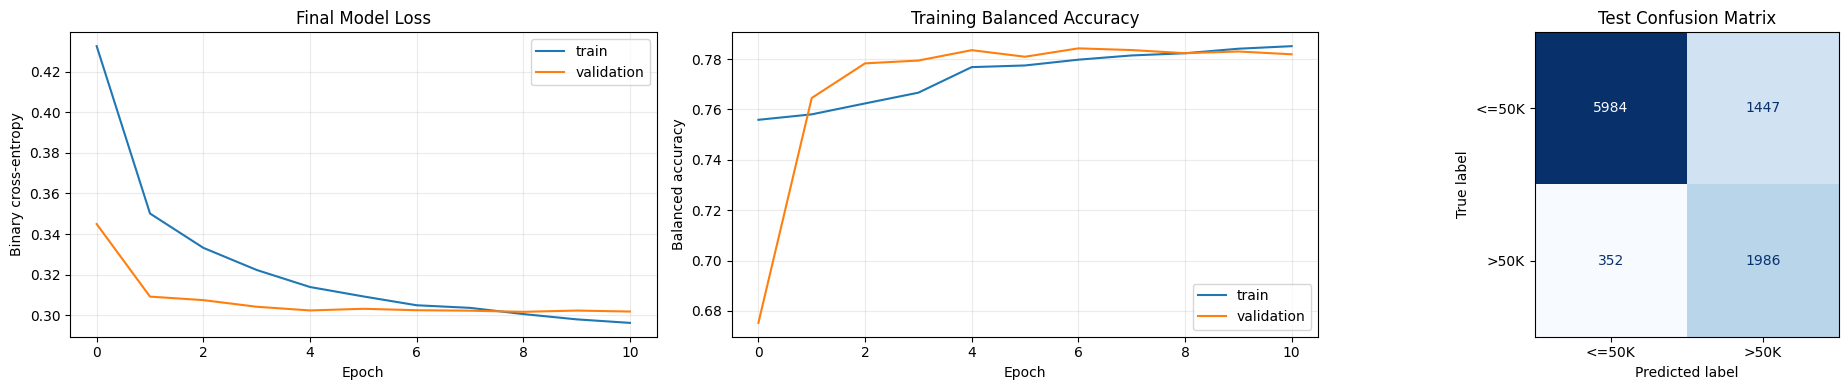

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
final_hist = pd.DataFrame(final_history.history)
### plot loss for final model train/validation
axes[0].plot(final_hist["loss"], label="train")
axes[0].plot(final_hist["val_loss"], label="validation")
axes[0].set_title("Final Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.25)
### plot balanced accuracy for final model train/validation at the default threshold
axes[1].plot(final_hist["balanced_accuracy"], label="train")
axes[1].plot(final_hist["val_balanced_accuracy"], label="validation")
axes[1].set_title("Training Balanced Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Balanced accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

### plot confusion matrix for test set using validation-selected threshold
ConfusionMatrixDisplay(final_test_cm, display_labels=["<=50K", ">50K"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("Test Confusion Matrix")

plt.tight_layout()
plt.show()


## Conclusions

Balanced accuracy is used as the main model-selection metric because the Adult income target is imbalanced. Unlike plain accuracy, it gives equal weight to performance on the `<=50K` and `>50K` classes.

To improve balanced accuracy without leaking information from the held-out test set, this notebook chooses the classification threshold using validation-set probabilities only. The chosen threshold is then applied once to the untouched test set.

In the final run, the best controlled experiment was the wider/deeper network with validation balanced accuracy of 0.7961. Optuna improved on that result with validation balanced accuracy of 0.8356 using a two-layer network with 256 units in each layer, dropout of 0.30, light L2 regularization, batch normalization, learning rate around 0.0007, and batch size 128.

The validation-selected threshold was 0.245. On the untouched held-out test set, the final tuned model reached accuracy of 0.8158, balanced accuracy of 0.8274, precision of 0.5785, recall of 0.8494, and F1 of 0.6883. This model is better aligned with balanced accuracy because it catches more of the minority `>50K` class, even though that creates more false positives and lowers plain accuracy.


In [26]:
### final summary and conclusion
best_controlled = experiment_results.sort_values("balanced_accuracy", ascending=False).iloc[0]
final_history_summary = summarize_history(final_history)

print(
    f"Best controlled experiment: {best_controlled['model']} "
    f"with validation balanced accuracy={best_controlled['balanced_accuracy']:.4f}, "
    f"F1={best_controlled['f1']:.4f}."
)
print(
    f"Optuna best validation balanced accuracy: {study.best_value:.4f} "
    f"across {len(study.trials)} trials."
)
print(f"Validation-selected threshold: {final_threshold:.3f}.")
print(
    f"Final model test performance: accuracy={final_test_metrics['accuracy']:.4f}, "
    f"balanced accuracy={final_test_metrics['balanced_accuracy']:.4f}, "
    f"precision={final_test_metrics['precision']:.4f}, "
    f"recall={final_test_metrics['recall']:.4f}, "
    f"F1={final_test_metrics['f1']:.4f}."
)
print(
    f"The final run stopped after {final_history_summary['epochs_run']} epochs; "
    f"its best validation balanced accuracy occurred at epoch {final_history_summary['best_epoch']} "
    "using the default 0.50 threshold during training."
)
print(
    "Conclusion: the selected neural network is supported by threshold-based balanced accuracy, "
    "the other classification metrics, the validation threshold search, and the train/validation curves. "
    "The test set was only used for final evaluation."
)


Best controlled experiment: Wider/deeper with validation balanced accuracy=0.7961, F1=0.6969.
Optuna best validation balanced accuracy: 0.8356 across 20 trials.
Validation-selected threshold: 0.245.
Final model test performance: accuracy=0.8158, balanced accuracy=0.8274, precision=0.5785, recall=0.8494, F1=0.6883.
The final run stopped after 11 epochs; its best validation balanced accuracy occurred at epoch 7 using the default 0.50 threshold during training.
Conclusion: the selected neural network is supported by threshold-based balanced accuracy, the other classification metrics, the validation threshold search, and the train/validation curves. The test set was only used for final evaluation.


## Personal Workflow for Future Neural Networks

In future neural network projects, I would start by clearly defining the target, checking the class balance, and separating a held-out test set before doing any modeling. After that, I would build a preprocessing pipeline that handles missing values, encodes categorical variables, and scales numeric variables using only the training data.

My first model would be a simple baseline network so I have a realistic comparison point. Then I would run controlled experiments where I change one major factor at a time, such as number of epochs, layer size, number and shape of layers, dropout, L2 regularization, learning rate, batch size, or early stopping settings. I would judge each change using validation metrics and the training/validation curves instead of only looking at final accuracy. 

Once I understand which choices help, I would use a systematic tuning method like Optuna or grid search to explore stronger combinations. For tabular classification problems, I would prioritize balanced accuracy, precision, recall, and F1 because accuracy alone can hide problems when the classes are imbalanced. I would also tune the classification threshold on validation data when the primary metric depends on a threshold.

The biggest best practices I would carry forward are to avoid data leakage, keep the test set untouched until the end, use early stopping to limit overfitting, set random seeds when comparing experiments, and always compare the final model against the baseline. A useful pitfall to remember is that a larger neural network is not automatically better; the validation curve is what shows whether added complexity is helping or just overfitting.
